# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Shriya |
| **Role** | Person 1 — `train.csv` Audit & Time Feature Extraction |
| **Notebook** | `Shriya_Train_Core_Audit.ipynb` |

---

## Sprint 1 — Data Exploration & Audit (`train.csv`)


SPRINT 1 TASKS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

print("Libraries loaded")

Libraries loaded


In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))  # go to main project folder

In [3]:
from shared.data_loader import load_train, load_test, load_metadata, load_weather_train, load_weather_test

Loading data

In [4]:
dtypes = {
    'building_id': np.int16,
    'meter': np.int8,
    'meter_reading': np.float32
}

train = pd.read_csv(
     'train.csv',
    dtype=dtypes,
    parse_dates=['timestamp']

)


print("Data loaded successfully")

Data loaded successfully


UNDERSTANDING DATA

In [5]:
print(train.shape)
train.head()
train.info()

(20216100, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int16         
 1   meter          int8          
 2   timestamp      datetime64[ns]
 3   meter_reading  float32       
dtypes: datetime64[ns](1), float32(1), int16(1), int8(1)
memory usage: 289.2 MB



DATA RANGE

In [6]:
print(train['timestamp'].min())
print(train['timestamp'].max())

2016-01-01 00:00:00
2016-12-31 23:00:00


In [7]:
print("Start date:", train['timestamp'].min())
print("End date:", train['timestamp'].max())

Start date: 2016-01-01 00:00:00
End date: 2016-12-31 23:00:00



COLUMNS

In [8]:
print(train.columns)

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')


In [9]:
train.columns = train.columns.str.strip().str.lower()
print(train.columns)

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')


BUILDINGS AND METERS

In [10]:
print("Unique buildings:", train['building_id'].nunique())
print("Unique meters:", train['meter'].nunique())

Unique buildings: 1449
Unique meters: 4


ZERO AND NEGATIVE VALUES

In [11]:
print("Zero readings:", (train['meter_reading'] == 0).sum())
print("Negative readings:", (train['meter_reading'] < 0).sum())

Zero readings: 1873976
Negative readings: 0


RAW DISTRIBUTION

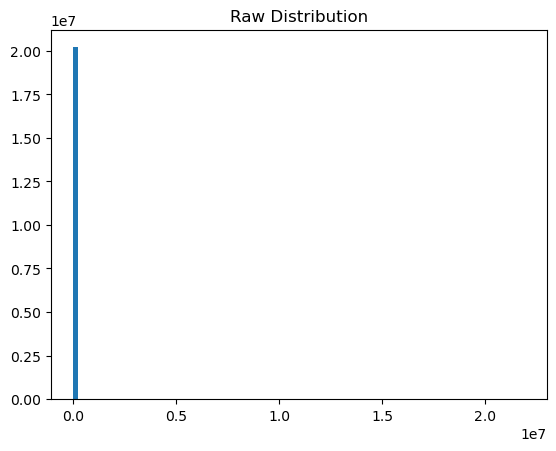

In [12]:
import matplotlib.pyplot as plt

plt.hist(train['meter_reading'], bins=100)
plt.title("Raw Distribution")
plt.show()

LOG DISTRIBUTION

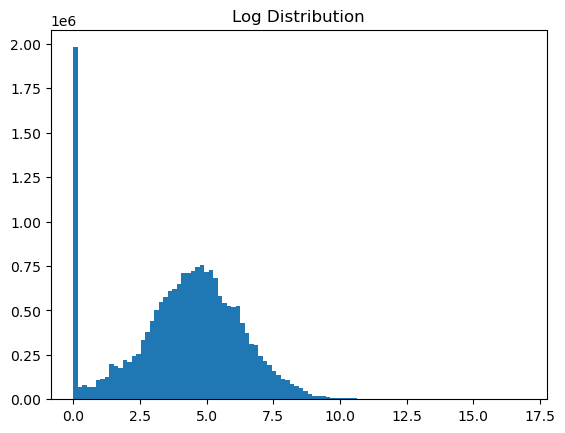

In [13]:
import numpy as np

plt.hist(np.log1p(train['meter_reading']), bins=100)
plt.title("Log Distribution")
plt.show()


METER COMBINATIONS

0 → Electricity, 1 → Chilled Water, 2 → Steam, 3 → Hot Water

In [14]:
meter_counts = train.groupby('building_id')['meter'].nunique()
print(meter_counts.value_counts())

meter
1    875
3    331
2    230
4     13
Name: count, dtype: int64



SUMMARY

Dataset contains 8165364 rows and 4 columns ('building_id', 'meter', 'timestamp', 'meter_reading')
Memory Usage: 116.8 MB
Covers time period from 2016-01-01 to 2016-05-31.
Contains 1441 unique buildings and 4 meter types.
Large number of zero readings observed (964396).
Negative readings are minimal but invalid.
Data distribution is highly skewed -makes it difficult to visually interpret patterns using the original scale. (majority of buildings use low energy, few buildings use extremely high energy)
Log transformation improved visualization - (smooth and spread out graph, we can clearly see the shape of the data, outliers are no longer dominating)
Meter combinations - most buildings are associated with only one type of meter(mostly electricity, while a smaller proportion have multiple meter types.

---

## Sprint 2 — Time Feature Extraction & Preprocessing


TIMESTAMP

In [15]:
train['timestamp'] = pd.to_datetime(train['timestamp'])


BASIC TIME FEATUIRES

day_of_week( 0 → Monday, 1 → Tuesday, 2 → Wednesday, 3 → Thursday, 4 → Friday, 5 → Saturday, 6 → Sunday)

In [16]:
train['hour'] = train['timestamp'].dt.hour
train['day_of_week'] = train['timestamp'].dt.dayofweek
train['month'] = train['timestamp'].dt.month
train['day_of_year'] = train['timestamp'].dt.dayofyear


WEEKEND FEATURE

0 → Weekday (Monday to Friday), 1 → Weekend (Saturday & Sunday)

In [17]:
train['is_weekend'] = (train['day_of_week'] >= 5).astype(int)

BUSINESS HOURS

0 → Not business hours, 1 → Business hours (8 AM to 6 PM, weekdays)

In [18]:
train['is_business_hours'] = (
    (train['hour'] >= 8) & 
    (train['hour'] <= 18) & 
    (train['day_of_week'] < 5)
).astype(int)
print(train[['hour','day_of_week','month']].head())

   hour  day_of_week  month
0     0            4      1
1     0            4      1
2     0            4      1
3     0            4      1
4     0            4      1


SEASON FEATURE

0 → Winter (Dec, Jan, Feb), 1 → Spring (Mar, Apr, May), 2 → Summer (Jun, Jul, Aug), 3 → Autumn (Sep, Oct, Nov)

In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # winter
    elif month in [3, 4, 5]:
        return 1  # spring
    elif month in [6, 7, 8]:
        return 2  # summer
    else:
        return 3  # autumn

train['season'] = train['month'].apply(get_season)

print(train[['month', 'season', 'hour', 'day_of_week', 'is_business_hours']].head())

   month  season  hour  day_of_week  is_business_hours
0      1       0     0            4                  0
1      1       0     0            4                  0
2      1       0     0            4                  0
3      1       0     0            4                  0
4      1       0     0            4                  0


LOG TRANSFORMATION

In [20]:
import numpy as np

train['log_meter_reading'] = np.log1p(train['meter_reading'])

In [21]:
train[['hour','day_of_week','month','is_weekend','is_business_hours','season','log_meter_reading']].head()

,hour,day_of_week,month,is_weekend,is_business_hours,season,log_meter_reading
0,0,4,1,0,0,0,0.0
1,0,4,1,0,0,0,0.0
2,0,4,1,0,0,0,0.0
3,0,4,1,0,0,0,0.0
4,0,4,1,0,0,0,0.0


BEFORE

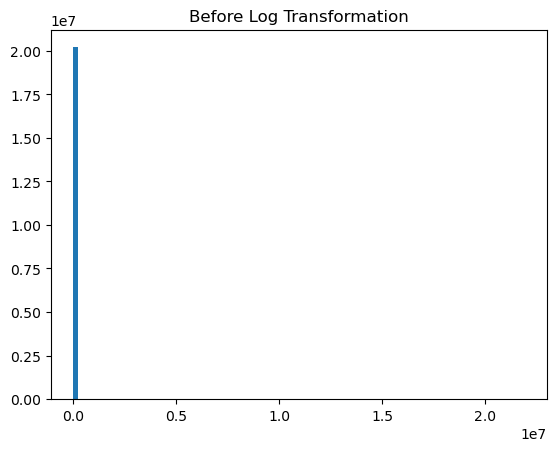

In [22]:
import matplotlib.pyplot as plt

plt.hist(train['meter_reading'], bins=100)
plt.title("Before Log Transformation")
plt.show()


AFTER

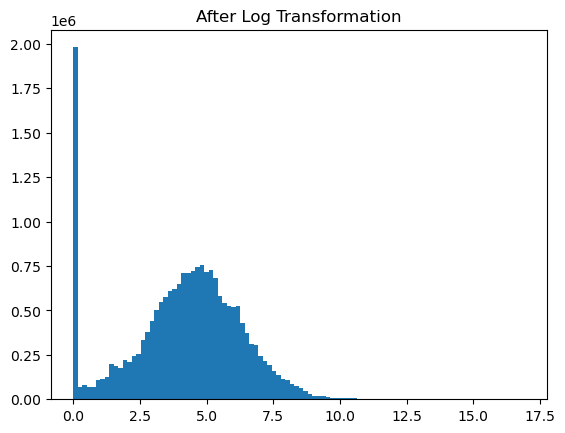

In [23]:
plt.hist(train['log_meter_reading'], bins=100)
plt.title("After Log Transformation")
plt.show()

In [24]:
train.head()

,building_id,meter,timestamp,meter_reading,hour,day_of_week,month,day_of_year,is_weekend,is_business_hours,season,log_meter_reading
0,0,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
1,1,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
2,2,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
3,3,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
4,4,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0


APPLY FEATURES TO MERGED FILES & SAVE

In [26]:
import os

data_dir = '/content/data_processed' if os.path.exists('/content') else os.path.join('..', 'data_processed')

# ── merged_train.csv ──────────────────────────────────────────────────────────
merged_train = pd.read_csv(os.path.join(data_dir, 'merged_train.csv'), parse_dates=['timestamp'])

merged_train['hour']              = merged_train['timestamp'].dt.hour
merged_train['day_of_week']       = merged_train['timestamp'].dt.dayofweek
merged_train['month']             = merged_train['timestamp'].dt.month
merged_train['day_of_year']       = merged_train['timestamp'].dt.dayofyear
merged_train['season']            = merged_train['month'].apply(get_season)
merged_train['is_weekend']        = (merged_train['day_of_week'] >= 5).astype(int)
merged_train['is_business_hours'] = (
    (merged_train['hour'] >= 8) & (merged_train['hour'] <= 18) &
    (merged_train['day_of_week'] < 5)
).astype(int)
merged_train['log_meter_reading'] = np.log1p(merged_train['meter_reading'])

# ── merged_test.csv ───────────────────────────────────────────────────────────
merged_test = pd.read_csv(os.path.join(data_dir, 'merged_test.csv'), parse_dates=['timestamp'])

merged_test['hour']              = merged_test['timestamp'].dt.hour
merged_test['day_of_week']       = merged_test['timestamp'].dt.dayofweek
merged_test['month']             = merged_test['timestamp'].dt.month
merged_test['day_of_year']       = merged_test['timestamp'].dt.dayofyear
merged_test['season']            = merged_test['month'].apply(get_season)
merged_test['is_weekend']        = (merged_test['day_of_week'] >= 5).astype(int)
merged_test['is_business_hours'] = (
    (merged_test['hour'] >= 8) & (merged_test['hour'] <= 18) &
    (merged_test['day_of_week'] < 5)
).astype(int)
# No log_meter_reading for test — test set has no meter_reading column

# ── Save ──────────────────────────────────────────────────────────────────────
merged_train.to_csv(os.path.join(data_dir, 'merged_train.csv'), index=False)
merged_test.to_csv(os.path.join(data_dir, 'merged_test.csv'),   index=False)

print("merged_train saved:", merged_train.shape, "| new cols:", [c for c in merged_train.columns if c not in ['building_id','meter','timestamp','meter_reading','site_id','primary_use','square_feet','year_built','floor_count','air_temperature','cloud_coverage','dew_temperature','precip_depth_1_hr','sea_level_pressure','wind_direction','wind_speed']])
print("merged_test  saved:", merged_test.shape,  "| new cols:", [c for c in merged_test.columns  if c not in ['row_id','building_id','meter','timestamp','site_id','primary_use','square_feet','year_built','floor_count','air_temperature','cloud_coverage','dew_temperature','precip_depth_1_hr','sea_level_pressure','wind_direction','wind_speed']])

merged_train saved: (20216100, 24) | new cols: ['hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading']
merged_test  saved: (41697600, 23) | new cols: ['hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours']


---

## Sprint 3 — Model Pipeline Contribution

Validation set: (2614072, 49)  date range 2016-11-08 00:00:00 to 2016-12-31 23:00:00
LightGBM            : RMSLE = 0.5084
XGBoost             : RMSLE = 0.5210
CatBoost (tuned)    : RMSLE = 0.5022


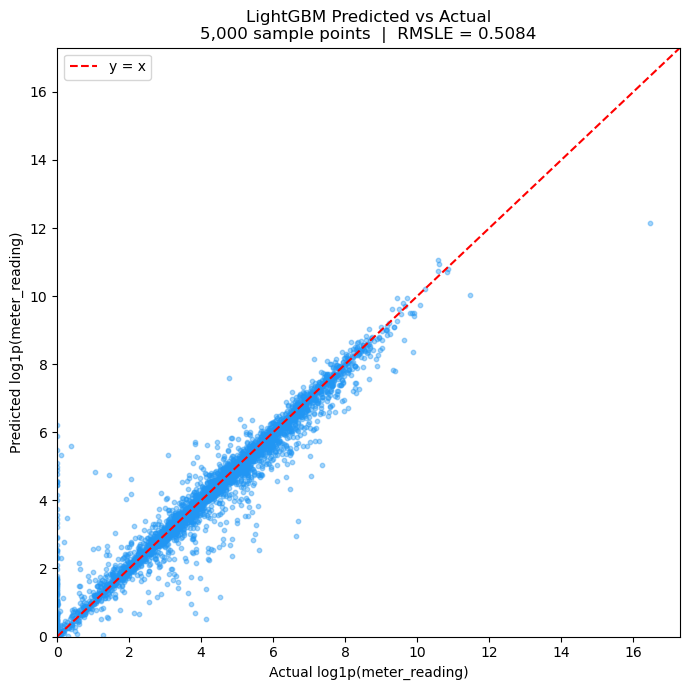

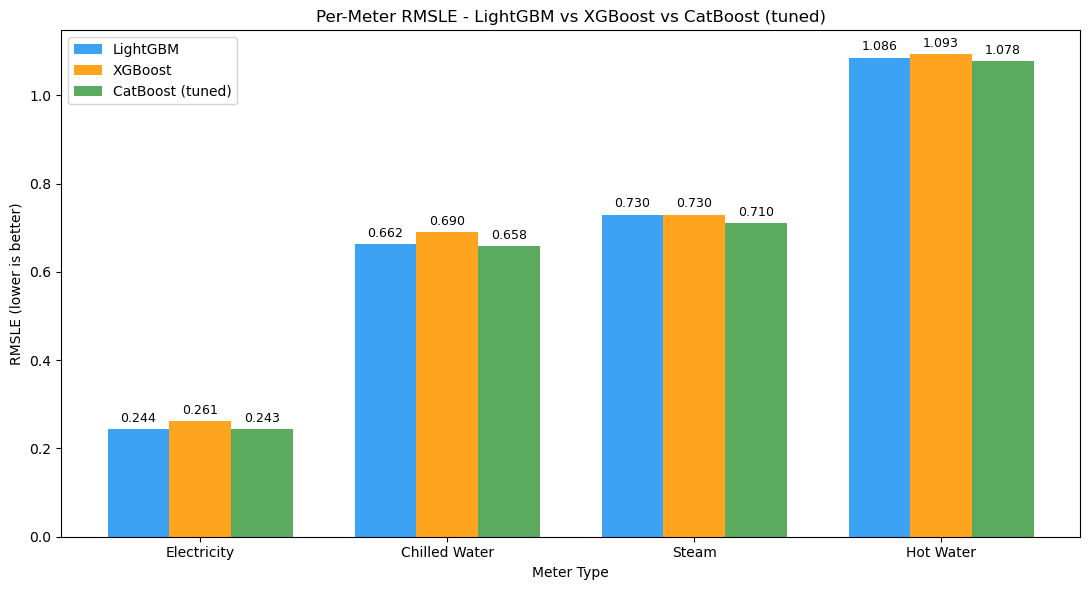

               LightGBM   XGBoost  CatBoost (tuned)
Electricity    0.243600  0.261200          0.243300
Chilled Water  0.662300  0.689600          0.657600
Steam          0.729800  0.729700          0.709800
Hot Water      1.085700  1.092700          1.078000
Overall        0.508401  0.520998          0.502159
Flags: none


In [1]:
import sys, os, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
from shared.metrics import rmsle

test = pd.read_csv("../data_processed/final_test_with_features.csv")
y_val     = test["meter_reading"].values
meter_col = test["meter"].values
print(f"Validation set: {test.shape}  date range {test['timestamp'].min()} to {test['timestamp'].max()}")

# building_id is kept here so models trained with it (LightGBM) score correctly;
# models trained without it just drop it via the reindex in get_X.
DROP_COLS = ['meter_reading', 'log_meter_reading', 'timestamp']

def get_X(df, model):
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    names = None
    for attr in ('feature_names_in_', 'feature_names_', 'feature_name_'):
        if hasattr(model, attr):
            v = getattr(model, attr)
            v = v() if callable(v) else v
            if v is not None and len(v) > 0:
                names = list(v); break
    if names is not None:
        X = X.reindex(columns=names, fill_value=0)
    return X.fillna(0)

models = {
    "LightGBM"        : joblib.load("../outputs/lightgbm_model.pkl"),
    "XGBoost"         : joblib.load("../outputs/xgb_model.pkl"),
    "CatBoost (tuned)": joblib.load("../outputs/cat_tuned_model.pkl"),
}

predictions, rmsles = {}, {}
for name, model in models.items():
    X = get_X(test, model)
    pred = np.expm1(np.maximum(model.predict(X), 0))
    predictions[name] = pred
    rmsles[name]      = rmsle(y_val, pred)
    print(f"{name:<20}: RMSLE = {rmsles[name]:.4f}")

# Predicted vs actual scatter for LightGBM (5,000 sampled points)
y_pred_lgb = predictions["LightGBM"]
rng = np.random.default_rng(42)
idx = rng.choice(len(y_val), 5000, replace=False)
actual_log = np.log1p(y_val[idx])
pred_log   = np.log1p(y_pred_lgb[idx])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual_log, pred_log, alpha=0.4, s=10, c="#2196F3")
m = max(actual_log.max(), pred_log.max()) * 1.05
ax.plot([0, m], [0, m], 'r--', linewidth=1.5, label='y = x')
ax.set_xlim(0, m); ax.set_ylim(0, m)
ax.set_xlabel('Actual log1p(meter_reading)')
ax.set_ylabel('Predicted log1p(meter_reading)')
ax.set_title(f'LightGBM Predicted vs Actual\n5,000 sample points  |  RMSLE = {rmsles["LightGBM"]:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/scatter_lightgbm_predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

# Per-meter RMSLE bar chart, 3 models side by side
METER_NAMES = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}
meters = sorted(METER_NAMES.keys())
labels = [METER_NAMES[m] for m in meters]

per_meter = {name: [] for name in models}
for name, pred in predictions.items():
    for m in meters:
        mask = meter_col == m
        per_meter[name].append(rmsle(y_val[mask], pred[mask]))

x = np.arange(len(labels)); width = 0.25
colors = ["#2196F3", "#FF9800", "#43A047"]
fig, ax = plt.subplots(figsize=(11, 6))
for i, (name, vals) in enumerate(per_meter.items()):
    bars = ax.bar(x + (i - 1) * width, vals, width, label=name, color=colors[i], alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Meter Type')
ax.set_ylabel('RMSLE (lower is better)')
ax.set_title('Per-Meter RMSLE - LightGBM vs XGBoost vs CatBoost (tuned)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/rmsle_per_meter_type_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

per_meter_df = pd.DataFrame(per_meter, index=labels).round(4)
per_meter_df.loc['Overall'] = [rmsles[name] for name in models]
print(per_meter_df)

flags = []
for name, pred in predictions.items():
    if (pred < 0).sum() > 0:
        flags.append(f"{name}: {(pred<0).sum()} negative predictions clipped to 0")
    if (pred > 1_000_000).sum() > 0:
        flags.append(f"{name}: {(pred>1_000_000).sum()} predictions over 1M kWh")
    if rmsles[name] > 1.0:
        flags.append(f"{name}: overall RMSLE {rmsles[name]:.4f} suspiciously high")
print("Flags:", flags if flags else "none")


---

## Sprint 4 — Evaluation & Report